In [58]:
import numpy as np

from skfda.datasets import fetch_aemet

X, y = fetch_aemet(return_X_y=True, as_frame=True)
fd = X.iloc[:, 0].array
temperature = fd.coordinates[0]
precipitation = fd.coordinates[1]

In [87]:
low_altitude = X["altitude"] < 250
labels = np.where(low_altitude, "low altitude", "high altitude")
y = np.where(low_altitude, 0, 1)  # 0 = low altitude, 1 = high altitude (binary label)

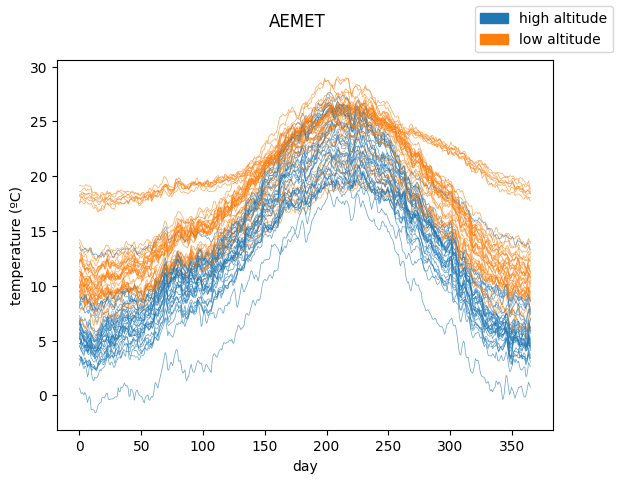

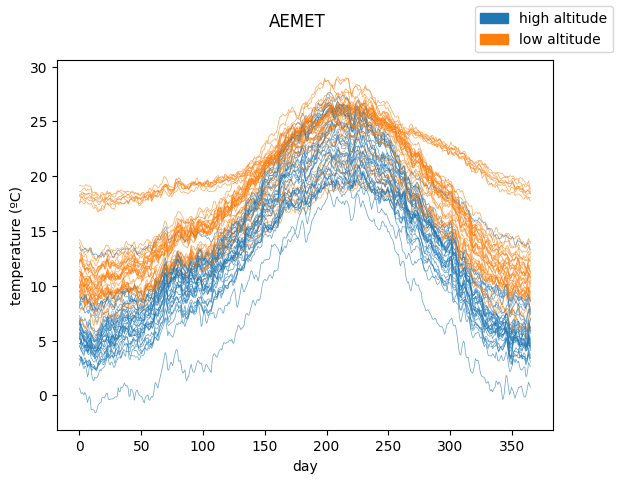

In [88]:
colors = {
    "low altitude": "red",
    "high altitude": "blue",
}

temperature.plot(
    group=labels,
    linewidth=0.5,
    alpha=0.7,
    legend=True,
)

In [89]:
max_temp = temperature.data_matrix.max(axis=-1)
max_precip = precipitation.data_matrix.max(axis=-1)

In [78]:
from sklearn.model_selection import train_test_split

(
    temp_train,
    temp_test,
    precip_train,
    precip_test,
    max_temp_train,
    max_temp_test,
    max_precip_train,
    max_precip_test,
    y_train,
    y_test,
) = train_test_split(
    temperature,
    precipitation,
    max_temp,
    max_precip,
    y,
    test_size=0.10,
    stratify=y,
    random_state=42,
)

In [95]:
from skfda.exploratory.stats import root_mean_square_l2
rms_temp = root_mean_square_l2(temp_train)
rms_precip = root_mean_square_l2(precip_train)
temp_train_scaled = temp_train / rms_temp
precip_train_scaled = precip_train / rms_precip
temp_test_scaled = temp_test / rms_temp
precip_test_scaled = precip_test / rms_precip

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scalar_train = scaler.fit_transform(np.column_stack([max_temp_train, max_precip_train]))
scalar_test = scaler.transform(np.column_stack([max_temp_test, max_precip_test]))

In [97]:
import pandas as pd

X_train = pd.DataFrame({
    "temperature": temp_train_scaled,
    "precipitation": precip_train_scaled,
    "max_temp": scalar_train[:, 0],
    "max_precip": scalar_train[:, 1],
})
X_test = pd.DataFrame({
    "temperature": temp_test_scaled,
    "precipitation": precip_test_scaled,
    "max_temp": scalar_test[:, 0],
    "max_precip": scalar_test[:, 1],
})

In [98]:
from skfda.misc.metrics import PProductMetric, default_metric, l2_distance

metric = PProductMetric(
    p=2,
    metrics=[l2_distance, l2_distance, default_metric, default_metric],
    weights=np.array([1, 1, 5, 5]),
)

In [114]:
from itertools import product

from sklearn.metrics import accuracy_score, make_scorer
from sklearn.model_selection import GridSearchCV

from skfda.ml.classification import KNeighborsClassifier

initial_metric = PProductMetric(
    p=2,
    metrics=[
        l2_distance,
        l2_distance,
        default_metric,
        default_metric,
    ],
    weights=np.array([1, 1, 1, 1]),  # initial
)

knn = KNeighborsClassifier(n_neighbors=5, metric=initial_metric)

# Weight values to explore
values = [0.5, 1, 2, 5, 10, 20]

# Symmetric configurations (functional weights equal, scalar weights equal)
all_weights = [np.array(p) for p in product(values, repeat=4)]

param_grid = {
    "metric__weights": all_weights,
}


grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring=make_scorer(accuracy_score),
    verbose=1,
)

grid.fit(X_train, y_train)

print("Best weights:", grid.best_params_["metric__weights"])
print("Best CV accuracy:", grid.best_score_)

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
Best weights: [10.   0.5 20.  20. ]
Best CV accuracy: 0.9384615384615385


In [115]:
y_pred = grid.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 87.50%


In [116]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(temp_train, y_train)

y_pred = knn.predict(temp_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 87.50%
